In [1]:
# import pandas as pd
# import pickle

# with open("Data_results/Bond_0.75/optimizer_result.pkl", "rb") as f:
#     results_75 = pickle.load(f)

# parameters_75 = results_75.x
# parameters_initial = [0.05928074, 0.07256101, -0.08495465]

# import pandas as pd

initial_parameters = {
    0.60: [0.05424044, 0.06461556, -0.09721599],
    0.70: [0.0821556, 0.03705277, -0.11171107],
    0.80: [0.07263012, 0.08563716, -0.03860591],
    0.90: [0.0735935, -0.06038758, -0.10268653]
}

# initial_parameters = pd.DataFrame(initial_parameters)
# print(initial_parameters)

In [ ]:
# from qiskit_ibm_runtime import QiskitRuntimeService, Estimator

# service = QiskitRuntimeService(name="TJ")
# service.active_account()
# print('Available backends:')
# print(service.backends(simulator=False))



qiskit_runtime_service.__init__:WARNING:2026-03-05 19:03:50,404: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-05 19:03:50,421: Loading instance: open-instance, plan: open


Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


In [ ]:
# # backend = service.least_busy(operational=True, simulator=False)
# backend = service.backend("ibm_fez")
# print(f"Backend = {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-03-05 19:04:00,354: Using instance: open-instance, plan: open


Backend = ibm_fez


## For Compiling on QPU


In [ ]:
# estimator = Estimator(mode=backend)       
# estimator.options.default_shots = 1024

## Local Compilation

In [2]:

from qiskit.primitives import StatevectorEstimator
estimator = StatevectorEstimator()


In [3]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit



from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()



from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

num_spatial_orbitals = 2
num_particles = (1, 1)
ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=HartreeFock(
        num_spatial_orbitals,
        num_particles,
        mapper,
    ),
)
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

# from qiskit.transpiler import PassManager
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
# target = backend.target
# pm = generate_preset_pass_manager(target=target, optimization_level=3)
# ansatz_isa = pm.run(ansatz)

from time import time


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []
energy_histories = []
optimal_parameters_list = []


# Bond lengths in Angstrom
bond_lengths = np.arange(0.30, 1.50, 0.05) 


for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy


    #print(f"Running VQE for bond length {r} Å with initial parameters: {initial_parameters[r]}")
    vqe_solver = VQE(estimator, ansatz, COBYLA())
    vqe_solver.initial_point = initial_parameters[0.70]       # IMPORTANT
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)

    H = main_operator
    hamiltonian = H #H.apply_layout(ansatz_isa.layout)

    energy_history = []

    def cost_func(params, ansatz, H, estimator):
        pub = (ansatz, [H], [params])
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]
        energy_history.append(energy)  
        return energy

    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz, hamiltonian, estimator),
        method="cobyla",
        options={"maxiter": 15, "disp": True},)

    optimizer_time = time() - start_time
    energy = result.fun
    optimal_parameters = result.x
    ground_state_energy = energy + nuclear_repulsion
    print(f"Ground state energy for bond length {r} Å: {ground_state_energy:.6f} Hartree")


    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)
    iteration_number.append(result.nfev)
    energy_histories.append(energy_history)
    optimal_parameters_list.append(optimal_parameters)





Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.3646829671216336
The corresponding X is:
[-0.01976307  0.0065897  -0.03842761]

Ground state energy for bond length 0.3 Å: -0.600759 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.3011172921511287
The corresponding X is:
[ 0.00200502  0.00584655 -0.0511955 ]

Ground state energy for bond length 0.35 Å: -0.789182 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.2362996123819108
The corresponding X is:
[-0.02059801  0.00564147 -0.05060115]

Ground state energy for bond length 0.39999999999999997 Å: -0.913357 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.17339453

In [4]:

# Create table
df = pd.DataFrame({
    "Bond Length": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies,
    "Convergence History": energy_histories,
    "optimal_parameters_list": optimal_parameters_list
})
#print(df)

In [5]:
# df.to_pickle("dataframe.pkl")
# df = pd.read_pickle("dataframe.pkl")

import pickle
location = "Data_results/Statevector_Results/Statevector_Results.pkl"
df.to_pickle(location)

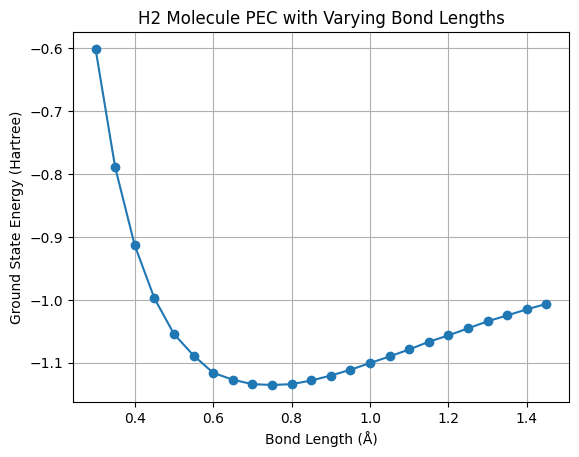

In [6]:
from matplotlib import pyplot as plt

plt.plot(bond_lengths, ground_energies, marker='o')
plt.grid(True)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Ground State Energy (Hartree)")
plt.title("H2 Molecule PEC with Varying Bond Lengths")
plt.show()

In [7]:
print(df[["Bond Length", "Ground State Energy (Hartree)"]])

    Bond Length  Ground State Energy (Hartree)
0          0.30                      -0.600759
1          0.35                      -0.789182
2          0.40                      -0.913357
3          0.45                      -0.997445
4          0.50                      -1.054337
5          0.55                      -1.088528
6          0.60                      -1.116049
7          0.65                      -1.127020
8          0.70                      -1.134055
9          0.75                      -1.135370
10         0.80                      -1.134099
11         0.85                      -1.128257
12         0.90                      -1.120386
13         0.95                      -1.111189
14         1.00                      -1.100452
15         1.05                      -1.089969
16         1.10                      -1.078781
17         1.15                      -1.066648
18         1.20                      -1.056434
19         1.25                      -1.045306
20         1.

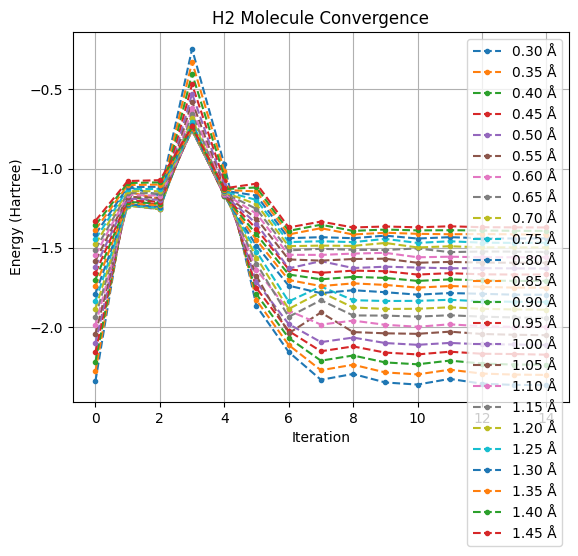

In [8]:
for history in energy_histories:
    plt.plot(history, marker='.', linestyle='--')
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("H2 Molecule Convergence")
plt.legend([f"{r:.2f} Å" for r in bond_lengths])
plt.show()

In [9]:
df.head(7)

,Bond Length,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.30,"{'x': [-0.019763072203464422, 0.00658970185559...",-0.600759,0.267545,1.763924,-2.364683,"[-2.340573527555158, -1.1155722069641365, -1.1...","[-0.019763072203464422, 0.0065897018555995945,..."
1,0.35,"{'x': [0.002005024661644707, 0.005846551962562...",-0.789182,0.228899,1.511935,-2.301117,"[-2.279420902628475, -1.1453831826424905, -1.1...","[0.002005024661644707, 0.0058465519625622965, ..."
2,0.40,"{'x': [-0.02059801123137401, 0.005641471995903...",-0.913357,0.166206,1.322943,-2.236300,"[-2.2184181081598573, -1.1713488089183308, -1....","[-0.02059801123137401, 0.005641471995903158, -..."
3,0.45,"{'x': [-0.01594725525986933, 0.006576564931376...",-0.997445,0.220123,1.175949,-2.173395,"[-2.158462301041319, -1.1928303594183982, -1.2...","[-0.01594725525986933, 0.0065765649313765774, ..."
4,0.50,"{'x': [-0.016419325527923436, 0.00578139633301...",-1.054337,0.190982,1.058354,-2.112692,"[-2.100007320448122, -1.2096042793649495, -1.2...","[-0.016419325527923436, 0.0057813963330108145,..."
5,0.55,"{'x': [0.04267409690405154, 0.0389120339863498...",-1.088528,0.256282,0.962140,-2.050669,"[-2.043265289685932, -1.2217289547728516, -1.2...","[0.04267409690405154, 0.0389120339863498, -0.0..."
6,0.60,"{'x': [-0.005676903382171844, -0.0091916187861...",-1.116049,0.186570,0.881962,-1.998011,"[-1.9883462678695967, -1.2294621437209592, -1....","[-0.005676903382171844, -0.009191618786169416,..."


ansatz depth = 4


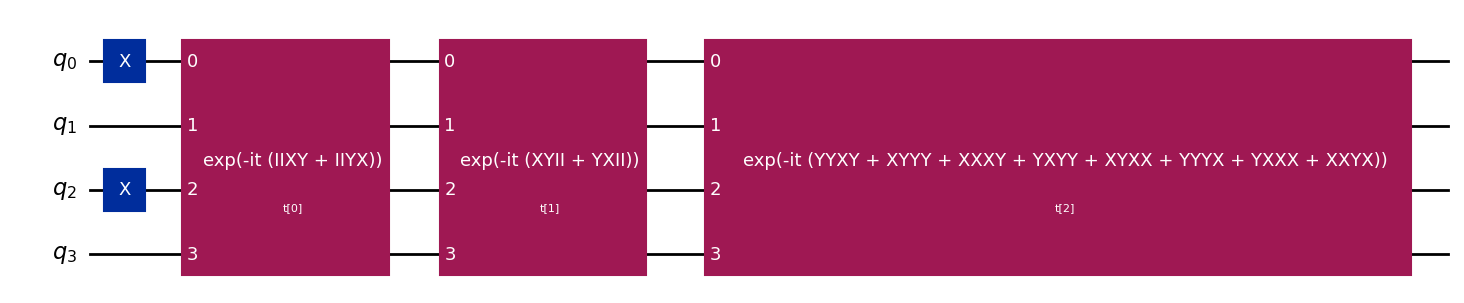

In [11]:
print(f"ansatz depth = {ansatz.decompose().depth()}")
ansatz.decompose().draw(output="mpl", idle_wires=False, style="iqp")

In [ ]:
# # Saving Data
# import os
# import pickle
# import json
# from qiskit import qpy
# from google.colab import drive

# # Mount Google Drive (safe if already mounted)
# drive.mount('/content/drive')

# save_dir = "/content/drive/MyDrive/vqe_experiment"
# os.makedirs(save_dir, exist_ok=True)

# # -----------------------------
# # 1. Save optimizer result
# # -----------------------------
# with open(os.path.join(save_dir, "optimizer_result.pkl"), "wb") as f:
#     pickle.dump(result, f)

# # -----------------------------
# # 2. Save optimized parameters
# # -----------------------------
# optimal_parameters = result.x
# with open(os.path.join(save_dir, "optimal_parameters.pkl"), "wb") as f:
#     pickle.dump(optimal_parameters, f)

# # -----------------------------
# # 3. Save Hamiltonian
# # -----------------------------
# with open(os.path.join(save_dir, "hamiltonian.pkl"), "wb") as f:
#     pickle.dump(hamiltonian_isa, f)

# # -----------------------------
# # 4. Save Ansatz Circuit
# # -----------------------------
# with open(os.path.join(save_dir, "ansatz.qpy"), "wb") as f:
#     qpy.dump(ansatz_isa, f)

# # -----------------------------
# # 5. Save backend information
# # -----------------------------
# backend_info = {
#     "backend_name": backend.name,
#     "num_qubits": backend.num_qubits,
#     "version": backend.version,
# }

# with open(os.path.join(save_dir, "backend_info.json"), "w") as f:
#     json.dump(backend_info, f, indent=4)

# # -----------------------------
# # 6. Save experiment metadata
# # -----------------------------
# experiment_metadata = {
#     "bond_length": float(r),
#     "basis": "sto3g",
#     "shots": estimator.options.default_shots,
#     "optimizer": "COBYLA",
#     "maxiter": 40,
#     "energy": float(energy),
#     "ground_state_energy": float(ground_state_energy),
#     "nuclear_repulsion_energy": float(nuclear_repulsion),
#     "iterations": result.nfev,
#     "optimizer_success": result.success,
#     "backend": backend.name
# }

# with open(os.path.join(save_dir, "experiment_metadata.json"), "w") as f:
#     json.dump(experiment_metadata, f, indent=4)

# # -----------------------------
# # 7. Save DataFrame results
# # -----------------------------
# df.to_pickle(os.path.join(save_dir, "results_dataframe.pkl"))
# df.to_csv(os.path.join(save_dir, "results_dataframe.csv"), index=False)

# # -----------------------------
# # 8. Save additional circuit info
# # -----------------------------
# circuit_info = {
#     "num_qubits": ansatz_isa.num_qubits,
#     "num_parameters": ansatz_isa.num_parameters,
#     "circuit_depth": ansatz_isa.depth()
# }

# with open(os.path.join(save_dir, "circuit_info.json"), "w") as f:
#     json.dump(circuit_info, f, indent=4)

# print("✅ All VQE experiment data saved in:")
# print(save_dir)

# # Optional: list files saved
# print("\nSaved files:")
# print(os.listdir(save_dir))